## 2.1 What is the CQT and why do we use it?

This notebook is to be used in tandem with `tutorial_notebook.ipynb`

The standard spectrogram (STFT) divides the frequency axis into **equally spaced** bins. This representation creates a problem for pitch: the same musical interval (say, one octave) corresponds to a *different number of bins* depending on where you are on the frequency axis. An octave at low frequencies spans far fewer bins than an octave at high frequencies.

The Constant-Q Transform (CQT) adresses this by using a **logarithmic frequency axis**, where each bin represents a fixed musical interval. Every semitone is represented by a the same fixed number of bins, regardless of octave.

This gives us an important property that we can make use of:

> **A pitch shift in audio = a translation (shift) in CQT bins.**

The "shape" of a note's CQT pattern does not change when you shift its pitch, it just slides vertically up or down by a fixed number of bins. This is the key property that the PESTO model learns to exploit.

In this notebook section we will take a look at some practical examples to observe this behaviour directly.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from nnAudio.features.cqt import CQT

In [13]:
# ── Config ────────────────────────────────────────────────────────────────────
# HCQT parameters
HARMONICS         = [1]       # which harmonics to use (1 = standard CQT)
HOP_DURATION_MS   = 10.0      # hop size in milliseconds
FMIN              = 27.5      # lowest frequency (A0)
BINS_PER_SEMITONE = 3         # frequency resolution
N_BINS            = 264       # total CQT bins (88 semitones * 3)
CENTER_BINS       = True

# Training
BATCH_SIZE  = 256
NUM_EPOCHS  = 10
LR          = 1e-4

# Loss weights
W_EQUIV = 1.0   # ShiftCrossEntropy  (equivariance — distribution shift)
W_FREQ  = 1.0   # PowerSeries        (equivariance — frequency ratio)
W_INV   = 1.0   # CrossEntropy       (invariance   — augmentation)

# Pitch shift range (in CQT bins, ± semitones * bins_per_semitone)
MAX_SHIFT = BINS_PER_SEMITONE * 11 // 2   # ~16 bins
MIN_SHIFT = -MAX_SHIFT

# Paths
DATA_DIR   = "data/mdb_stem_synth"
CACHE_PATH = "cache/hcqt_train.pt"
TRAIN_CSV  = "train_files.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


In [ ]:
class CQTModule(nn.Module):
    """Simplified CQT module for a single harmonic."""
    def __init__(self, sr, hop_length, fmin, bins_per_semitone, n_bins, center_bins):
        super().__init__()
        
        # Adjust fmin if center_bins is True so centers land on semitone boundaries
        if center_bins:
            fmin = fmin / 2 ** ((bins_per_semitone - 1) / (24 * bins_per_semitone))

        # Standard CQT kernel from nnAudio
        self.cqt_kernel = CQT(
            sr=sr, 
            hop_length=hop_length, 
            fmin=fmin, 
            n_bins=n_bins,
            bins_per_octave=12 * bins_per_semitone, 
            output_format="Complex", 
            verbose=False
        )

    def forward(self, audio):
        # Result shape: (batch, freq_bins, time, 2)
        return self.cqt_kernel(audio)

In [ ]:
# helper function: generate a synthetic harmonic tone at a given MIDI pitch
def make_tone(midi_pitch, sr=16000, duration=3.0, n_harmonics=6):
    f0 = 440.0 * 2 ** ((midi_pitch - 69) / 12)
    t  = torch.arange(0, duration, 1 / sr)
    # Sum harmonics with decaying amplitudes
    wave = sum(
        (1 / k) * torch.cos(2 * torch.pi * k * f0 * t)
        for k in range(1, n_harmonics + 1)
    )
    return wave / wave.abs().max()   # normalise

In [ ]:

SR = 16000
HOP = int(HOP_DURATION_MS * SR / 1000)

# initialize cqt module once and reuse for all tones
cqt_module = CQTModule(
    sr=SR, hop_length=HOP,
    fmin=FMIN, bins_per_semitone=BINS_PER_SEMITONE,
    n_bins=N_BINS, center_bins=CENTER_BINS
).to(DEVICE)

def get_cqt(midi_pitch):
    """Return log-magnitude CQT of a synthetic tone, shape (freq_bins, time)."""
    audio = make_tone(midi_pitch, sr=SR).to(DEVICE)
    with torch.no_grad():
        # Input shape: (1, samples) -> Output: (1, freq_bins, time, 2)
        cqt_out = cqt_module(audio.unsqueeze(0)) 
        
        # Remove batch dim and handle complex view
        cqt_complex = torch.view_as_complex(cqt_out.squeeze(0).float()) # (freq_bins, time)
        
        # Log-magnitude conversion
        log_mag = cqt_complex.abs().clamp(min=1e-7).log10().mul(20)
        
    return log_mag.cpu().numpy() # (freq_bins, time)

In [ ]:
class PitchShiftCQT(nn.Module):
    """
    Module to perform batch-wise pitch shifting on CQT spectrograms.
    """
    def __init__(self, min_steps: int, max_steps: int):
        super().__init__()
        self.min_steps = min_steps
        self.max_steps = max_steps
        self.lower_bin = max_steps 

    def forward(self, spectrograms: torch.Tensor):
        """
        Args:
            spectrograms: Tensor of shape (Batch, Freq, Time)
        Returns:
            x: Reference crop
            xt: Shifted crop
            n_steps: Shift amount per sample
        """
        batch_size, n_bins, n_frames = spectrograms.shape
        output_height = n_bins - (self.max_steps - self.min_steps)
        
        # Sample random shifts
        n_steps = torch.randint(self.min_steps, self.max_steps + 1, (batch_size,), 
                                device=spectrograms.device)

        # Extract Reference crop (x)
        x = spectrograms[:, self.lower_bin : self.lower_bin + output_height, :]

        # Extract Shifted crop (xt)
        first_bins = self.lower_bin - n_steps
        xt = self.extract_bins(spectrograms, first_bins, output_height)

        return x, xt, n_steps

    def extract_bins(self, inputs, first_bins, output_height):
        batch_size, _, n_frames = inputs.shape
        # Create grid of indices (Batch, output_height)
        indices = first_bins.unsqueeze(-1) + torch.arange(output_height, device=inputs.device)
        # Expand to (Batch, output_height, Time) to gather across the Freq dimension
        indices = indices.unsqueeze(-1).expand(-1, -1, n_frames)
        return torch.gather(inputs, 1, indices)

### STFT vs CQT: the same two notes one octave apart

Below we plot the STFT and CQT of two notes that are one octave apart:

     **C4 (MIDI 60)** and **C5 (MIDI 72)**

Notice what happens on each axis:
- In the **STFT**, C5 spans many more bins than C4.
- In the **CQT**, C5 is exactly 36 bins above C4 (12 semitones × 3 bins per semitone).

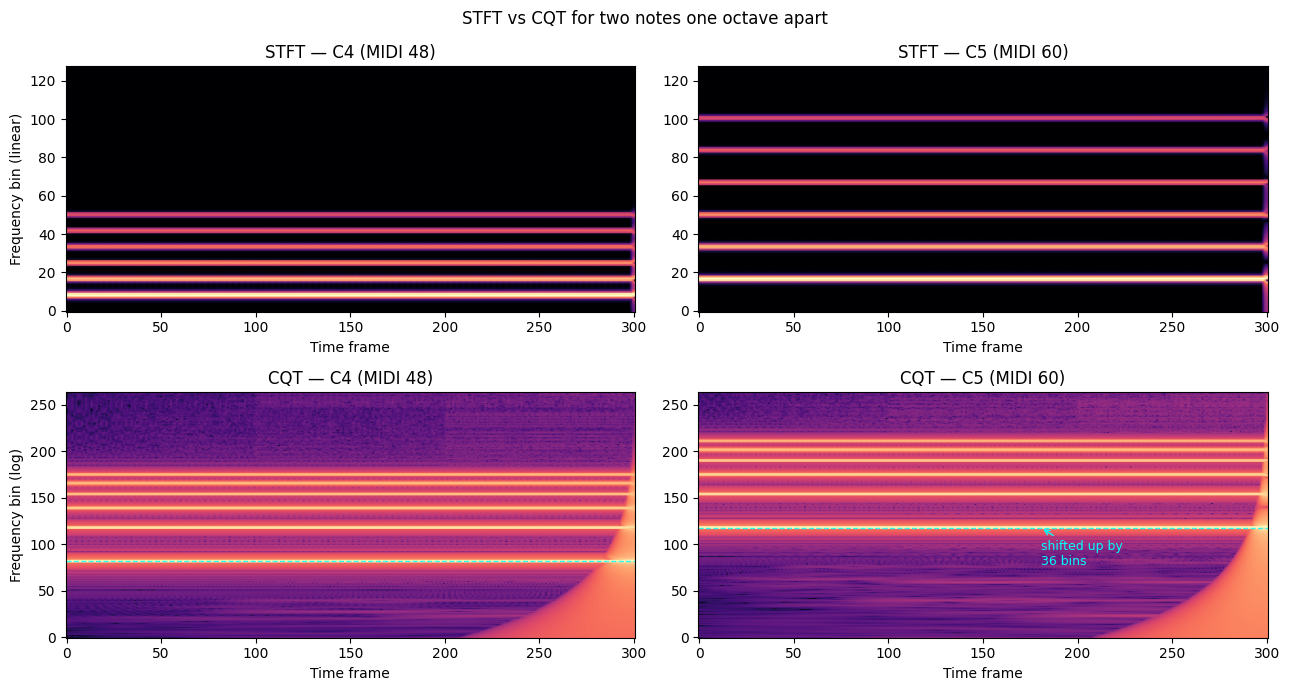

CQT peak of C4: bin 82
CQT peak of C5: bin 118
Difference: 36 bins  (expected: 36)


In [16]:
import torchaudio.transforms as T

midi_low  = 48   # C4
midi_high = 60   # C5  (one octave up)

audio_low  = make_tone(midi_low,  sr=SR)
audio_high = make_tone(midi_high, sr=SR)

# STFT
stft_transform = T.Spectrogram(n_fft=1024, hop_length=HOP, power=2)
stft_low  = stft_transform(audio_low).log1p().numpy()
stft_high = stft_transform(audio_high).log1p().numpy()

# CQT
cqt_low  = get_cqt(midi_low)
cqt_high = get_cqt(midi_high)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("STFT vs CQT for two notes one octave apart", fontsize=12)

kw = dict(aspect="auto", origin="lower", cmap="magma")

# STFT row — zoom to relevant frequency range
freq_max_bin = stft_low.shape[0] // 4   # zoom to lower quarter
axes[0, 0].imshow(stft_low[:freq_max_bin],  **kw)
axes[0, 1].imshow(stft_high[:freq_max_bin], **kw)
axes[0, 0].set_title(f"STFT — C4 (MIDI {midi_low})")
axes[0, 1].set_title(f"STFT — C5 (MIDI {midi_high})")
axes[0, 0].set_ylabel("Frequency bin (linear)")

# CQT row
axes[1, 0].imshow(cqt_low,  **kw)
axes[1, 1].imshow(cqt_high, **kw)
axes[1, 0].set_title(f"CQT — C4 (MIDI {midi_low})")
axes[1, 1].set_title(f"CQT — C5 (MIDI {midi_high})")
axes[1, 0].set_ylabel("Frequency bin (log)")

# Annotate the CQT shift
bin_shift = (midi_high - midi_low) * BINS_PER_SEMITONE
peak_low  = cqt_low.max(axis=1).argmax()
peak_high = cqt_high.max(axis=1).argmax()
for ax, peak in [(axes[1, 0], peak_low), (axes[1, 1], peak_high)]:
    ax.axhline(peak, color="cyan", linewidth=1, linestyle="--", alpha=0.8)

axes[1, 1].annotate(
    f"shifted up by\n{bin_shift} bins",
    xy=(cqt_high.shape[1] * 0.6, peak_high),
    xytext=(cqt_high.shape[1] * 0.6, peak_high - 40),
    color="cyan", fontsize=9,
    arrowprops=dict(arrowstyle="->", color="cyan")
)

for ax in axes.flat:
    ax.set_xlabel("Time frame")

plt.tight_layout()
plt.show()

print(f"CQT peak of C4: bin {peak_low}")
print(f"CQT peak of C5: bin {peak_high}")
print(f"Difference: {peak_high - peak_low} bins  (expected: {bin_shift})")

### The CQT translation property across a wider pitch range

Let's have a look at another example. Below we take a single octave of notes (C3 to B3) and plot a single frame from each CQTs.

Below you should see the same harmonic pattern, just shifted up by 3 bins per semitone.

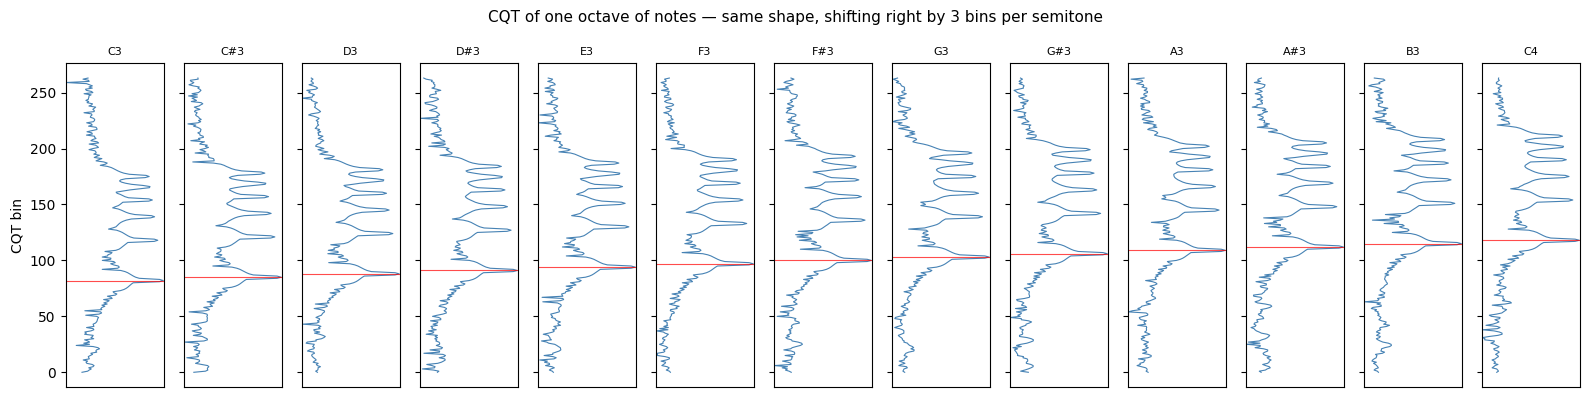

Note   | Peak bin | Shift from C3
-----------------------------------
C3     |       82 | +0 bins
C#3    |       85 | +3 bins
D3     |       88 | +6 bins
D#3    |       91 | +9 bins
E3     |       94 | +12 bins
F3     |       97 | +15 bins
F#3    |      100 | +18 bins
G3     |      103 | +21 bins
G#3    |      106 | +24 bins
A3     |      109 | +27 bins
A#3    |      112 | +30 bins
B3     |      115 | +33 bins
C4     |      118 | +36 bins


In [ ]:
# One frame from the middle of each note's CQT
notes_midi  = list(range(48, 61))   # C3 to C4
note_names  = ["C3","C#3","D3","D#3","E3","F3","F#3","G3","G#3","A3","A#3","B3","C4"]
mid_frame   = 50   # pick a steady-state frame

fig, axes = plt.subplots(1, len(notes_midi), figsize=(16, 4), sharey=True)
fig.suptitle(
    "CQT of one octave of notes, shifting right by 3 bins per semitone",
    fontsize=11
)

for i, (midi, name) in enumerate(zip(notes_midi, note_names)):
    cqt = get_cqt(midi)                        # (freq_bins, time)
    frame = cqt[:, mid_frame]                  # single time frame

    axes[i].plot(frame, np.arange(len(frame)), color="steelblue", linewidth=0.8)
    axes[i].set_title(name, fontsize=8)
    axes[i].set_xlim(frame.min() - 1, frame.max() + 1)
    axes[i].axhline(np.argmax(frame), color="red", linewidth=0.8, alpha=0.7)
    if i == 0:
        axes[i].set_ylabel("CQT bin")
    axes[i].set_xticks([])

plt.tight_layout()
plt.show()

# Print the peak bin for each note to show the exact shift
peaks = []
for midi in notes_midi:
    cqt = get_cqt(midi)
    peaks.append(np.argmax(cqt[:, mid_frame]))

print("Note   | Peak bin | Shift from C3")
print("-" * 35)
for name, peak in zip(note_names, peaks):
    print(f"{name:6s} | {peak:8d} | +{peak - peaks[0]} bins")

### Simulating a change in pitch with crop augmentations

The table printed above demonstrates that every note semitone adds preciscley **3 bins** (what we define as our `BINS_PER_SEMITONE` configuration). Self supervised learning approaches can exploit this regularity, we don't need labels!

To make use of this concept with real training data reliably we can create artificial pitch shifts using a simply cropping the CQT.

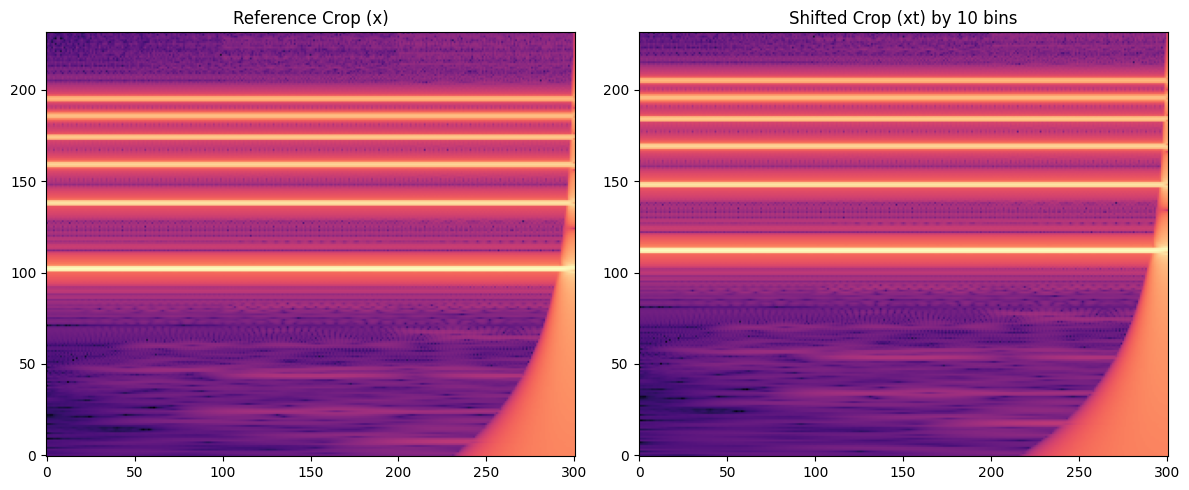

Shift amount: 10 bins (3.33 semitones)


In [ ]:
# Generate a synthetic tone (e.g., Middle C / MIDI 60)
midi_pitch = 60
spectrogram = get_cqt(midi_pitch) # returns (freq_bins, time)

# Convert to torch tensor and add batch dimension: (1, Freq, Time)
spec_tensor = torch.from_numpy(spectrogram).unsqueeze(0).to(DEVICE)

# Initialize the shifter with the defined range
# MAX_SHIFT is ~16 bins based on the config
shifter = PitchShiftCQT(min_steps=MIN_SHIFT, max_steps=MAX_SHIFT).to(DEVICE)

# Perform the shift
# x is the reference crop, xt is the shifted version
x, xt, n_steps = shifter(spec_tensor)

# Visualise!
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(x[0].cpu(), **kw)
ax[0].set_title("Reference Crop (x)")

ax[1].imshow(xt[0].cpu(), **kw)
ax[1].set_title(f"Shifted Crop (xt) by {n_steps.item()} bins")

plt.tight_layout()
plt.show()

print(f"Shift amount: {n_steps.item()} bins "
      f"({n_steps.item()/BINS_PER_SEMITONE:.2f} semitones)")

### Summary

Equivariant self supervised learning for pitch tracking follows more or less these following steps

1. Take any CQT frame `x`
2. Shift it by `n` bins to get `x_shifted` — this simulates a pitch shift of `n/BINS_PER_SEMITONE` semitones
3. Train the model so that its output for `x_shifted` is a predictable transformation of its output for `x`

The model never needs to know the actual pitch of any note. It simply needs to learn that its outputs are **consistent with shifts**. If it says `x` has pitch `p`, it must say `x_shifted` has pitch `p + n/BINS_PER_SEMITONE`. This consistency constraint, applied across thousands of frame pairs, is enough to learn a meaningful pitch representation from un-labelled data.


To link back to the main notebook. The `PitchShiftCQT` module in our code implements step 2, and the three loss functions help to implement step 3.